In [1]:
import pandas as pd
import numpy as np

In [2]:
data=pd.read_csv(r'C:\\ABHIRAM\projects\FifaWCPredictor\data\international_results\results.csv')
data.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
data['tournament'].unique().tolist()

['Friendly',
 'British Home Championship',
 'Évence Coppée Trophy',
 'Muratti Vase',
 'Copa Lipton',
 'Copa Newton',
 'Copa Premio Honor Argentino',
 'Olympic Games',
 'Copa Premio Honor Uruguayo',
 'Far Eastern Championship Games',
 'Copa Roca',
 'Copa América',
 'Inter-Allied Games',
 'Peace Cup',
 'Open International Championship',
 'Soccer Ashes',
 'Copa Chevallier Boutell',
 'Nordic Championship',
 'Central European International Cup',
 'Baltic Cup',
 'Balkan Cup',
 'Central American and Caribbean Games',
 'FIFA World Cup',
 'Copa Rio Branco',
 'FIFA World Cup qualification',
 'Bolivarian Games',
 'CCCF Championship',
 'NAFC Championship',
 'Copa Oswaldo Cruz',
 'Asian Games',
 'Pan American Championship',
 'Copa del Pacífico',
 "Copa Bernardo O'Higgins",
 'AFC Asian Cup qualification',
 'Atlantic Cup',
 'AFC Asian Cup',
 'African Cup of Nations',
 'Copa Paz del Chaco',
 'Merdeka Tournament',
 'UEFA Euro qualification',
 'Southeast Asian Peninsular Games',
 'African Friendship Gam

In [4]:
data['home_team'].unique()

<StringArray>
[        'Scotland',          'England',            'Wales',
 'Northern Ireland',    'United States',          'Uruguay',
          'Austria',          'Hungary',        'Argentina',
          'Belgium',
 ...
     'Saint Helena',       'West Papua',      'Elba Island',
    'Yoruba Nation',           'Biafra',          'Mapuche',
           'Aymara',           'Ticino',            'Hmong',
 'Marshall Islands']
Length: 327, dtype: str

In [5]:
data['date'].dtype

<StringDtype(storage='python', na_value=nan)>

In [6]:
data.isnull().sum()

date           0
home_team      0
away_team      0
home_score    64
away_score    64
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [7]:
#convert string date to datetime

data['date']=pd.to_datetime(data['date'])

In [8]:
data['date'].dtype

dtype('<M8[us]')

In [9]:
data.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [10]:
#Sort by date
data=data.sort_values(by='date')


In [11]:
data=data[(data['date'].dt.year>=2000) & (data['date'].dt.year<=2025)]
data=data.reset_index(drop=True)

In [12]:
tier1 = {"FIFA World Cup", "UEFA Euro", "Copa América", "African Cup of Nations",
         "AFC Asian Cup", "Gold Cup", "Confederations Cup", "CONCACAF Championship"}

tier3 = {"CECAFA Cup", "Gulf Cup", "AFF Championship", "AFF Championship qualification",
         "ASEAN Championship", "ASEAN Championship qualification", "COSAFA Cup",
         "COSAFA Cup qualification", "Arab Cup", "Arab Cup qualification",
         "CFU Caribbean Cup", "CFU Caribbean Cup qualification", "UNCAF Cup", "SAFF Cup",
         "WAFF Championship", "EAFF Championship", "EAFF Championship qualification",
         "AFC Challenge Cup", "AFC Challenge Cup qualification", "Oceania Nations Cup",
         "Oceania Nations Cup qualification", "NAFU Championship", "NAFC Championship",
         "Pan American Championship", "CCCF Championship", "Nordic Championship",
         "Central European International Cup", "Baltic Cup", "Balkan Cup",
         "British Home Championship", "Korea Cup", "King's Cup", "Kirin Cup",
         "Kirin Challenge Cup", "Merdeka Tournament", "Mundialito", "Intercontinental Cup",
         "CAFA Nations Cup"}

exclude_keywords = ["Games", "CONIFA", "ConIFA"]
exclude_exact = {"Viva World Cup", "GaNEFo", "The Other Final", "FIFI Wild Cup"}

def get_tier(name):
    if name in tier1:
        return 1
    if "qualification" in name and (name.replace(" qualification", "") in tier1 or name in {"UEFA Nations League", "CONCACAF Nations League",
                                                  "CONCACAF Nations League qualification"}):
        return 2
    if name == "UEFA Nations League" or name == "CONCACAF Nations League":
        return 2
    if name in tier3:
        return 3
    if name == "Friendly":
        return 4
    if any(k in name for k in exclude_keywords) or name in exclude_exact:
        return 0
    return 0  

data['tier']=data['tournament'].apply(get_tier)

In [13]:
# insert a new column for the outcome
#home win=1, away won=0, draw=0.5
conditions=[
    data['home_score']>data['away_score'],
    data['home_score']==data['away_score'],
    data['home_score']<data['away_score'],
]

values=[1,0.5,0]

data['outcome_home']=np.select(conditions,values,default=0)

In [14]:
data['outcome_home'].value_counts()

outcome_home
1.0    12048
0.0     7158
0.5     5826
Name: count, dtype: int64

In [15]:
#Elo system
BASE=1500
elo_ratings={}
elo_home=[]
elo_away=[]

def get_elo(team):
    return elo_ratings.get(team,BASE)

def expected_score(elo_a,elo_b):
    return 1/(1+10**((elo_b-elo_a)/400))

def goal_multiplier(goal_diff):
    if abs(goal_diff)<=1: return 1
    elif abs(goal_diff)==2: return 1.5
    elif abs(goal_diff)==3: return 1.75
    elif abs(goal_diff)>=4: return 1.75+(abs(goal_diff)-3)/8

#tier k factor
tier_k={0:0, 1:40, 2:30, 3:20, 4:10}

for index,row in data.iterrows():
    elo_home_team=get_elo(row['home_team'])
    elo_away_team=get_elo(row['away_team'])
    elo_home.append(elo_home_team)
    elo_away.append(elo_away_team)

    expected_home_score=expected_score(elo_home_team,elo_away_team)
    actual_home_score=row['outcome_home']
    
    goal_diff=row['home_score']-row['away_score']
    # tier=get_tier(row['tournament'])
    tier=row['tier']

    k_base=tier_k[tier]
    k_effective=k_base*goal_multiplier(goal_diff)

    elo_ratings[row['home_team']]=elo_home_team+k_effective*(actual_home_score-expected_home_score)
    elo_ratings[row['away_team']]=elo_away_team+k_effective*((1-actual_home_score)-(1-expected_home_score))

data['elo_home']=elo_home
data['elo_away']=elo_away
data['elo_diff']=data['elo_home']-data['elo_away']
    






In [16]:
final_elo = pd.Series(elo_ratings).sort_values(ascending=False)
print(final_elo.head(25))

Spain            2094.511881
Argentina        2060.581531
France           2005.460090
England          1992.108729
Brazil           1953.505823
Colombia         1949.832113
Japan            1943.266287
Portugal         1925.904618
Netherlands      1922.144352
Germany          1917.345185
Morocco          1912.061618
Mexico           1898.186234
Ecuador          1889.870069
Iran             1885.621564
Uruguay          1881.558890
South Korea      1880.428004
United States    1875.252350
Croatia          1869.731595
Senegal          1863.928480
Australia        1847.532422
Switzerland      1839.716021
Italy            1836.019638
Canada           1835.136469
Norway           1830.467894
Algeria          1830.128606
dtype: float64


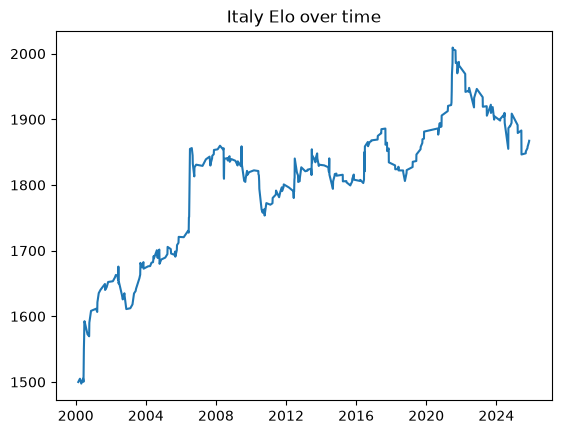

In [17]:
import matplotlib.pyplot as plt

team = "Italy"
mask = (data['home_team'] == team) | (data['away_team'] == team)
team_data = data[mask].copy()
team_data['team_elo'] = team_data.apply(
    lambda r: r['elo_home'] if r['home_team'] == team else r['elo_away'], axis=1
)

plt.plot(team_data['date'], team_data['team_elo'])
plt.title(f"{team} Elo over time")
plt.show()

In [26]:
import joblib

joblib.dump(elo_ratings,r'C:\ABHIRAM\projects\FifaWCPredictor\models\elo_ratings.pkl')

['C:\\ABHIRAM\\projects\\FifaWCPredictor\\models\\elo_ratings.pkl']

In [25]:
data.to_csv(r'C:\\ABHIRAM\projects\FifaWCPredictor\data\Processed_result.csv',index=False)